In [1]:
# Standard imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import warnings
from scipy.sparse import csr_matrix
import numpy as np
import matplotlib.ticker as ticker
import matplotlib as mpl

from datetime import datetime
from tqdm import tqdm
# import csr_matrix
from scipy.sparse import csr_matrix
# Suppress noisy warnings
warnings.filterwarnings("ignore")

# Plotting configuration (Seaborn + Matplotlib harmony)
sns.set_theme(context="notebook", style="white")  # minimal, clean
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'grid.color': 'white'
})

# Optional: consistent color palette
sns.set_palette("colorblind")

# Print today's date
today = datetime.now().strftime("%Y%m%d")
print(f"Today's date: {today}")

# LeafletFA source code and utilities
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"
shared_utils_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/"

# Add custom module paths
for path in [src_path, shared_utils_path]:
    if path not in sys.path:
        sys.path.append(path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds
from utils import * 
from figure_plotting import *

Today's date: 20250815


In [2]:
# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


### Load data

In [3]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"

# Output directory
output_dir = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper"
print(f"Saving plots to {output_dir}")

# Look at all the junctions that are in original anndata (not just the ones used in model training):
SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/072025/aligned_splicing_data_20250730_164104.h5ad"

# Get the ATSE file
ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

# Read in full splice adata 
splice_adata_full = ad.read_h5ad(SPLICE_INPUT)
print(f"Done loading splice adata!")

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"
print(f"Done loading ATSE file!")

# Junction ortho mapping
junc_orthos = "/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/plots_2025-07-30/junction_mapping_mouse_human_with_annotations.csv"
junc_orthos = pd.read_csv(junc_orthos)

Saving plots to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper
Done loading splice adata!
Done loading ATSE file!


### Clean up the age column 

In [4]:
# Convert age strings like "2m" to integer months
# subset for this analysis to no 2m old cells 
splice_adata_full.obs["age"] = splice_adata_full.obs["age"].str.replace("m", "").astype(int)

# Define young and old groups based on integer age
splice_adata_full.obs["age_group"] = splice_adata_full.obs["age"].apply(
    lambda x: "young" if x in [2, 3] else "old"
)

print(splice_adata_full.obs["age"].value_counts())

age
2     49308
3     33760
24    27470
18    27398
Name: count, dtype: int64


In [5]:
# save to excel spreadsheet summary of broad cell type and more sepcific cell type breakdowns 
full_obs = splice_adata_full.obs.copy()

# save datasets used for plots in separate excel spreadsheet 

### Plots summarizing junction annotations

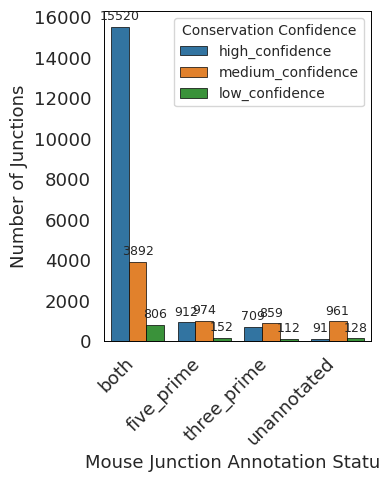

In [6]:
fig, ax = plt.subplots(figsize=(4, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

sns.countplot(
    data=junc_orthos,
    x="mouse_annotation_status",
    hue="conservation_confidence",
    hue_order=["high_confidence", "medium_confidence", "low_confidence"],
    palette=["#1f77b4", "#ff7f0e", "#2ca02c"],
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.set_xlabel("Mouse Junction Annotation Status", fontsize=13)
ax.set_ylabel("Number of Junctions", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

ax.legend(
    title="Conservation Confidence",
    title_fontsize=10,
    fontsize=10,
    loc="upper right",
    frameon=True
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

# Make all spines black
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.7)

plt.tight_layout()
# Save as PDF
plt.savefig(os.path.join(output_dir, f"annotation_status_barplot_{today}.pdf"), format='pdf', bbox_inches='tight')
plt.show()

In [7]:
# Initialize the column with default value
splice_adata_full.var["junction_conserved"] = "conservation_unknown"

# Create set of conserved junction IDs for fast lookup
conserved_junction_ids = set(junc_orthos["mouse_junction_id"])
print(f"Total junctions in splice_adata: {splice_adata_full.var.shape[0]:,}")
print(f"Conserved junctions in mapping: {len(conserved_junction_ids):,}")

# Mark conserved junctions
conserved_mask = splice_adata_full.var["junction_id"].isin(conserved_junction_ids)
splice_adata_full.var.loc[conserved_mask, "junction_conserved"] = "conserved"

# Summary statistics
conserved_count = (splice_adata_full.var["junction_conserved"] == "conserved").sum()
not_conserved_count = (splice_adata_full.var["junction_conserved"] == "conservation_unknown").sum()

# Ensure clean string format
splice_adata_full.var["annotation_conservation_group"] = (
    splice_adata_full.var["annotation_status"].astype(str) + "_" + splice_adata_full.var["junction_conserved"].astype(str)
)

print(f"\nConservation labeling results:")
print(f"  Conserved junctions: {conserved_count:,} ({conserved_count/len(splice_adata_full.var)*100:.1f}%)")
print(f"  Not conserved: {not_conserved_count:,} ({not_conserved_count/len(splice_adata_full.var)*100:.1f}%)")

Total junctions in splice_adata: 124,378
Conserved junctions in mapping: 25,116

Conservation labeling results:
  Conserved junctions: 23,040 (18.5%)
  Not conserved: 101,338 (81.5%)


### Get suitable broad cell types for preliminary aging analysis (remove 2months old neurons from this analysis!)

In [8]:
# Step 1: Get counts
counts = splice_adata_full.obs.groupby(["medium_cell_type", "age"]).size().unstack(fill_value=0)
# Step 2: Drop age group 2 from consideration
counts_filtered = counts.drop(columns=[2], errors='ignore')

# Step 3: Check which cell types have at least 50 cells in ≥2 age groups (excluding age 2)
valid_celltypes = counts_filtered.apply(lambda row: (row >= 50).sum() >= 2, axis=1)

# Step 4: Get the list of valid cell types
valid_celltype_list = counts_filtered[valid_celltypes].index.tolist()

print("✔️ Retained cell types:")
for ct in valid_celltype_list:
    print(f"  - {ct}")

# Subset the adata to only include the valid cell types
splice_adata_full = splice_adata_full[splice_adata_full.obs["medium_cell_type"].isin(valid_celltype_list)].copy()
print(f"Subsetting to {len(valid_celltype_list)} cell types... with {splice_adata_full.n_obs} cells")

✔️ Retained cell types:
  - Astrocyte
  - B cell
  - Bladder cell
  - Cardiac stromal cell
  - Cardiomyocyte
  - Dendritic cell
  - Endothelial cell
  - Epithelial stem cell
  - Fibroblast
  - Granulocyte
  - Hematopoietic progenitor
  - Hematopoietic stem cell
  - Hepatocyte
  - Immune progenitor
  - Intestinal epithelial cell
  - Kidney epithelial cell
  - Kidney tubular cell
  - Macrophage
  - Mesenchymal stem cell
  - Microglia
  - Monocyte
  - Nk cell
  - Oligodendrocyte
  - Other epithelial cell
  - Other immune cell
  - Other neuron
  - Pancreatic ductal cell
  - Pancreatic endocrine cell
  - Pancreatic exocrine cell
  - Pericyte
  - Respiratory epithelial cell
  - Secretory cell
  - Skeletal muscle cell
  - Skin epithelial cell
  - Smooth muscle cell
  - Specialized endothelial cell
  - Specialized intestinal cell
  - Stromal cell
  - T cell
  - T cell precursor
  - Urogenital epithelial cell
Subsetting to 41 cell types... with 86035 cells


### Summarize junction coverage statistics across cells

In [9]:
print("🔍 Computing junction statistics...")

# Fetch junction matrix
junction_matrix = splice_adata_full.layers["cell_by_junction_matrix"]

# Compute per-junction stats
non_zero_cells = (junction_matrix > 0).sum(axis=0)
total_reads = junction_matrix.sum(axis=0)

splice_adata_full.var["non_zero_count_cells"] = np.asarray(non_zero_cells).flatten()
splice_adata_full.var["non_zero_cell_prop"] = splice_adata_full.var["non_zero_count_cells"] / splice_adata_full.n_obs
splice_adata_full.var["total_read_counts"] = np.asarray(total_reads).flatten()
splice_adata_full.var["mean_counts_per_cell"] = np.divide(
    splice_adata_full.var["total_read_counts"],
    splice_adata_full.var["non_zero_count_cells"],
    out=np.zeros_like(splice_adata_full.var["total_read_counts"]),
    where=splice_adata_full.var["non_zero_count_cells"] > 0
)

# Junction-level read count breakdown by annotation
is_annotated = splice_adata_full.var["annotation_status"] == "both"
is_unannotated = ~is_annotated

# Compute per-junction annotated/unannotated read counts
annotated_counts = np.asarray(junction_matrix[:, is_annotated].sum(axis=0)).flatten()
unannotated_counts = np.asarray(junction_matrix[:, is_unannotated].sum(axis=0)).flatten()

# Store with NaN where not applicable
splice_adata_full.var.loc[is_annotated, "annotated_read_counts"] = annotated_counts
splice_adata_full.var.loc[is_unannotated, "unannotated_read_counts"] = unannotated_counts
splice_adata_full.var["annotated_read_counts"] = splice_adata_full.var["annotated_read_counts"].fillna(0).astype(int)
splice_adata_full.var["unannotated_read_counts"] = splice_adata_full.var["unannotated_read_counts"].fillna(0).astype(int)

# Print summary
print("📊 Junction Detection Summary (Non-zero Count Cells):")
print(splice_adata_full.var["non_zero_count_cells"].agg(["min", "max", "mean", "median"]).to_string())

print("\n📊 Junction Read Count Summary (Total Read Counts):")
print(splice_adata_full.var["total_read_counts"].agg(["min", "max", "mean", "median"]).to_string())

# Identify junctions with zero support
zero_support = splice_adata_full.var.query("non_zero_count_cells == 0 or total_read_counts == 0")
print(f"\n⚠️  {len(zero_support):,} junctions with zero support in all cells.")

# Compute per-cell read totals
splice_adata_full.obs["total_junction_reads"] = np.asarray(junction_matrix.sum(axis=1)).flatten()
splice_adata_full.obs["annotated_junction_reads"] = np.asarray(junction_matrix[:, is_annotated].sum(axis=1)).flatten()
splice_adata_full.obs["unannotated_junction_reads"] = np.asarray(junction_matrix[:, is_unannotated].sum(axis=1)).flatten()

# Compute per-cell detection counts
detected_matrix = junction_matrix > 0
splice_adata_full.obs["n_detected_annotated_junctions"] = np.asarray(detected_matrix[:, is_annotated].sum(axis=1)).flatten()
splice_adata_full.obs["n_detected_unannotated_junctions"] = np.asarray(detected_matrix[:, is_unannotated].sum(axis=1)).flatten()

🔍 Computing junction statistics...
📊 Junction Detection Summary (Non-zero Count Cells):
min           0.00000
max       79936.00000
mean       1295.38629
median       78.00000

📊 Junction Read Count Summary (Total Read Counts):
min       0.000000e+00
max       5.820853e+07
mean      6.024264e+04
median    1.382000e+03

⚠️  6,753 junctions with zero support in all cells.


In [10]:
# print junctions that have zero non_zero_count_cells or total_read_counts
splice_adata_full.var[(splice_adata_full.var["non_zero_count_cells"] == 0) | (splice_adata_full.var["total_read_counts"] == 0)]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,...,n_cells_detected,confidence,junction_conserved,annotation_conservation_group,non_zero_count_cells,non_zero_cell_prop,total_read_counts,mean_counts_per_cell,annotated_read_counts,unannotated_read_counts
50,chr10_101681950_102011732_+,ENSMUSG00000019888.16_atse_1,GT-AG,both,MGAT4C,ENSMUSG00000019888.16,10,0.0,1.0,4473,...,919,high,conservation_unknown,both_conservation_unknown,0,0.0,0,0,0,0
53,chr10_101864030_101866676_+,ENSMUSG00000019888.16_atse_1,GT-AG,five_prime,MGAT4C,ENSMUSG00000019888.16,10,0.0,NaN,8939,...,1279,high,conservation_unknown,five_prime_conservation_unknown,0,0.0,0,0,0,0
54,chr10_101864030_101889302_+,ENSMUSG00000019888.16_atse_1,GT-AG,both,MGAT4C,ENSMUSG00000019888.16,10,0.0,1.0,11981,...,1697,high,conservation_unknown,both_conservation_unknown,0,0.0,0,0,0,0
55,chr10_101864030_101935819_+,ENSMUSG00000019888.16_atse_1,GT-AG,five_prime,MGAT4C,ENSMUSG00000019888.16,10,0.0,NaN,3430,...,576,high,conservation_unknown,five_prime_conservation_unknown,0,0.0,0,0,0,0
57,chr10_101866756_101889302_+,ENSMUSG00000019888.16_atse_1,GT-AG,three_prime,MGAT4C,ENSMUSG00000019888.16,10,NaN,1.0,1362,...,200,high,conservation_unknown,three_prime_conservation_unknown,0,0.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162976,chrY_1216511_1224496_-,ENSMUSG00000068457.14_atse_4,GT-AG,five_prime,UTY,ENSMUSG00000068457.14,5,1.0,NaN,917,...,165,high,conservation_unknown,five_prime_conservation_unknown,0,0.0,0,0,0,0
163051,chrY_916710_916845_+,ENSMUSG00000056673.14_atse_4,GT-AG,three_prime,KDM5D,ENSMUSG00000056673.14,2,50.0,1.0,578,...,136,high,conserved,three_prime_conserved,0,0.0,0,0,0,0
163059,chrY_938171_940023_+,ENSMUSG00000056673.14_atse_7,GT-AG,five_prime,KDM5D,ENSMUSG00000056673.14,2,0.0,NaN,159,...,38,low,conservation_unknown,five_prime_conservation_unknown,0,0.0,0,0,0,0
163061,chrY_940240_940598_+,ENSMUSG00000056673.14_atse_8,GT-AG,three_prime,KDM5D,ENSMUSG00000056673.14,2,NaN,1.0,168,...,36,low,conservation_unknown,three_prime_conservation_unknown,0,0.0,0,0,0,0


### Calculate raw junction usage ratios values

In [11]:
# Get matrices
A = splice_adata_full.layers["cell_by_junction_matrix"].tocsr()
B = splice_adata_full.layers["cell_by_cluster_matrix"].tocsr()

# Sanity check: same sparsity structure
assert np.array_equal(A.indices, B.indices), "Mismatch in indices"
assert np.array_equal(A.indptr, B.indptr), "Mismatch in indptr"

# Element-wise safe division
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_data = np.true_divide(A.data, B.data)
    #ratio_data[~np.isfinite(ratio_data)] = 0.0  # Replace NaN or inf with 0.0

# Reconstruct CSR matrix
junc_ratio_csr = csr_matrix((ratio_data, A.indices, A.indptr), shape=A.shape)

# Store in AnnData
splice_adata_full.layers["junc_ratio"] = junc_ratio_csr
splice_adata_full.layers["junc_ratio"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 424107600 stored elements and shape (86035, 124378)>

In [12]:
splice_adata_full.layers["junc_ratio"].data

array([1., 0., 0., ..., 0., 1., 0.])

### Get cell type versus age groups mean and median junction usage 

In [13]:
# Initialize container
records = []

# Get junction IDs and groups
junction_ids = splice_adata_full.var["junction_id"].values
cell_types = splice_adata_full.obs["broad_cell_type"].unique()
age_groups = splice_adata_full.obs["age_group"].unique()

# Iterate over cell type × age groups
for ct in cell_types:
    for age in age_groups:
        mask = (splice_adata_full.obs["broad_cell_type"] == ct) & (splice_adata_full.obs["age_group"] == age)
        n_cells = mask.sum()

        if n_cells < 50:
            continue  # skip small groups

        psi = splice_adata_full[mask].layers["junc_ratio"]  # shape: (n_cells, n_junctions)
        psi_dense = psi.toarray()  # convert sparse matrix to dense

        mean_psi = psi_dense.mean(axis=0)
        median_psi = np.median(psi_dense, axis=0)

        for junc_idx, junc_id in tqdm(enumerate(junction_ids), total=len(junction_ids)):
            records.append({
                "junction_id": junc_id,
                "cell_type": ct,
                "age_group": age,
                "mean_psi": mean_psi[junc_idx],
                "median_psi": median_psi[junc_idx],
                "n_cells": n_cells
            })
        
        print(f"Finished processing junctions for {ct} {age}")

# Assemble into long-form DataFrame
psi_long = pd.DataFrame.from_records(records)

100%|██████████| 124378/124378 [00:00<00:00, 750205.13it/s]


Finished processing junctions for Epithelial cell old


100%|██████████| 124378/124378 [00:00<00:00, 803940.10it/s]


Finished processing junctions for Epithelial cell young


100%|██████████| 124378/124378 [00:00<00:00, 777751.49it/s]


...

Finished processing junctions for Kidney cell young


100%|██████████| 124378/124378 [00:00<00:00, 978627.92it/s]


Finished processing junctions for Bladder cell old


100%|██████████| 124378/124378 [00:00<00:00, 981332.20it/s]


Finished processing junctions for Bladder cell young


In [41]:
# Pivot to have age as columns
pivot_df = psi_long.pivot_table(index=["junction_id", "cell_type"], columns="age_group", values="mean_psi")

# Drop incomplete pairs (missing old or young)
pivot_df = pivot_df.dropna()

# Compute ΔPSI (old - young)
pivot_df["delta_psi"] = pivot_df["old"] - pivot_df["young"]
pivot_df = pivot_df.reset_index()
pivot_df.head()

age_group,junction_id,cell_type,old,young,delta_psi
0,chr10_100016035_100051845_+,Bladder cell,0.064024,0.025253,0.038772
1,chr10_100016035_100051845_+,Cardiac cell,0.062112,0.143947,-0.081835
2,chr10_100016035_100051845_+,Epithelial cell,0.034709,0.065767,-0.031058
3,chr10_100016035_100051845_+,Fenestrated cell,0.246154,0.343396,-0.097242
4,chr10_100016035_100051845_+,Glial cell,0.011403,0.019881,-0.008478


In [42]:
pivot_df[(pivot_df["delta_psi"] < -0.05) | (pivot_df["delta_psi"] > 0.05)]["junction_id"].nunique()

16792

Each value here is a junction-cell type pair!


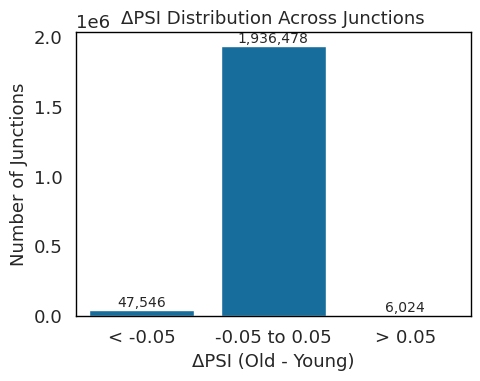

In [15]:
# Bin into categories
pivot_df["delta_psi_bin"] = pd.cut(
    pivot_df["delta_psi"],
    bins=[-np.inf, -0.05, 0.05, np.inf],
    labels=["< -0.05", "-0.05 to 0.05", "> 0.05"]
)

# Plot count bar plot with annotations
plt.figure(figsize=(5, 4))
ax = sns.countplot(data=pivot_df, x="delta_psi_bin", order=["< -0.05", "-0.05 to 0.05", "> 0.05"])
plt.title("ΔPSI Distribution Across Junctions")
plt.xlabel("ΔPSI (Old - Young)")
plt.ylabel("Number of Junctions")

# Add text annotations on top of bars
print(f"Each value here is a junction-cell type pair!")
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count:,}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/delta_psi_per_celltype_2025-08-15.pdf


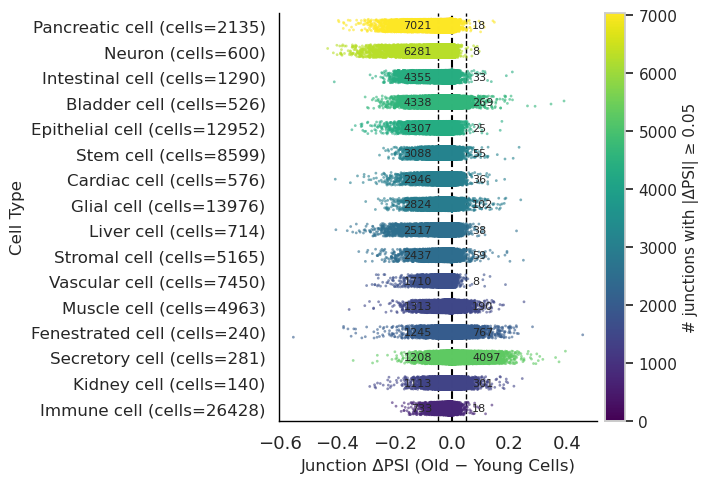

In [16]:
from datetime import date

# ------------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------------
threshold = 0.05                     # |ΔPSI| cut-off
order_by  = "n_lt"                   # metric that decides row order
ascending = False                    # largest → smallest
today     = date.today().isoformat() # for the PDF file name
# ------------------------------------------------------------------

# --- 1. Per-cell-type summary table --------------------------------
celltype_stats = (
    pivot_df
    .groupby("cell_type")
    .agg(
        median_psi = ("delta_psi", "median"),
        n_total    = ("delta_psi", "size"),
        n_gt       = ("delta_psi", lambda s: (s >  threshold).sum()),
        n_lt       = ("delta_psi", lambda s: (s < -threshold).sum())
    )
)

# add #cells in the original AnnData object
cell_counts = splice_adata_full.obs["broad_cell_type"].value_counts()
celltype_stats["n_cells"] = cell_counts.reindex(celltype_stats.index).fillna(0).astype(int)

# label for the y-axis
celltype_stats["label"] = [
    f"{ct} (cells={n})" for ct, n in zip(celltype_stats.index, celltype_stats["n_cells"])
]

# final sort + index reset  (crucial for correct y-positions)
celltype_stats = (
    celltype_stats
    .sort_values(order_by, ascending=ascending)
    .reset_index()       # now row 0 ↔ top strip
)

# convenient variables for plotting
ordered = celltype_stats["cell_type"].tolist()
labels  = celltype_stats["label"].tolist()

# --- 2. Colour map keyed to the median ΔPSI ------------------------
#norm     = mpl.colors.Normalize(celltype_stats["median_psi"].min(),
#                                celltype_stats["median_psi"].max())
#cmap     = plt.cm.coolwarm
#pal_dict = {ct: cmap(norm(med)) for ct, med in
#            zip(celltype_stats["cell_type"], celltype_stats["median_psi"])}

celltype_stats["n_sig"] = celltype_stats["n_lt"] + celltype_stats["n_gt"]

vmax = max(1, celltype_stats["n_sig"].max())  # avoid degenerate norm
norm = mpl.colors.Normalize(vmin=0, vmax=vmax)
cmap = plt.cm.viridis  # any sequential map is fine

pal_dict = {
    ct: cmap(norm(n))
    for ct, n in zip(celltype_stats["cell_type"], celltype_stats["n_sig"])
}

# --- 3. Plot -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
sns.set(style="whitegrid", context="notebook")

sns.stripplot(
    data   = pivot_df,
    y      = "cell_type",
    x      = "delta_psi",
    order  = ordered,
    palette= pal_dict,
    size   = 2,
    jitter = 0.25,
    alpha  = 0.6,
    ax     = ax
)

# rasterise the dots so exported PDF/SVG remain small
for coll in ax.collections:
    coll.set_rasterized(True)

mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(mappable, ax=ax, pad=0.02)
cbar.set_label(f"# junctions with |ΔPSI| ≥ {threshold}", fontsize=11)

# reference lines
ax.axvline(0,          ls="--", lw=1.5, color="black")
ax.axvline( threshold, ls="--", lw=1,   color="black")
ax.axvline(-threshold, ls="--", lw=1,   color="black")

# annotate counts beyond ±threshold
for yloc, row in celltype_stats.iterrows():
    if row.n_lt:
        ax.text(-threshold - 0.02, yloc, int(row.n_lt),
                ha="right", va="center", fontsize=8)
    if row.n_gt:
        ax.text( threshold + 0.02, yloc, int(row.n_gt),
                ha="left",  va="center", fontsize=8)

# y-axis labels
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=12)

# axis titles
ax.set_xlabel("Junction ΔPSI (Old − Young Cells)", fontsize=12)
ax.set_ylabel("Cell Type",                         fontsize=12)

sns.despine()
fig.tight_layout()

outfile = os.path.join(output_dir, f"delta_psi_per_celltype_{today}.pdf")
fig.savefig(outfile, dpi=300, bbox_inches="tight")
print(f"Saved to {outfile}")

In [17]:
pivot_df[pivot_df["cell_type"] == "Stromal cell"]["delta_psi_bin"].value_counts()

delta_psi_bin
-0.05 to 0.05    121882
< -0.05            2437
> 0.05               59
Name: count, dtype: int64

In [18]:
# Group by cell type and delta_psi_bin
bin_counts = (
    pivot_df.groupby(["cell_type", "delta_psi_bin"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
bin_counts.columns.name = None  # remove group name for clean print

bin_fractions = bin_counts.copy()
total = bin_fractions[["< -0.05", "-0.05 to 0.05", "> 0.05"]].sum(axis=1)
for col in ["< -0.05", "-0.05 to 0.05", "> 0.05"]:
    bin_fractions[col] = (bin_fractions[col] / total).round(3)

bin_fractions["n_total"] = total
bin_fractions

,cell_type,< -0.05,-0.05 to 0.05,> 0.05,n_total
0,Bladder cell,0.035,0.963,0.002,124378
1,Cardiac cell,0.024,0.976,0.000,124378
2,Epithelial cell,0.035,0.965,0.000,124378
3,Fenestrated cell,0.010,0.984,0.006,124378
4,Glial cell,0.023,0.976,0.001,124378
5,Immune cell,0.006,0.994,0.000,124378
6,Intestinal cell,0.035,0.965,0.000,124378
7,Kidney cell,0.009,0.989,0.002,124378
8,Liver cell,0.020,0.979,0.000,124378
9,Muscle cell,0.011,0.988,0.002,124378


### Find exon skipping junctions

In [19]:
# Subset to ATSEs with exactly 3 junctions
atse_counts = splice_adata_full.var.groupby("event_id")["junction_id"].count()
candidate_atse = atse_counts[atse_counts == 3].index

# Pull junctions from those candidate ATSEs
subset = splice_adata_full.var[splice_adata_full.var["event_id"].isin(candidate_atse)].copy()

# Sort them by event_id and junction start
subset[["chr", "start", "end", "strand"]] = subset["junction_id"].str.extract(r"(chr[\w]+)_(\d+)_(\d+)_([+-])")
subset["start"] = subset["start"].astype(int)
subset["end"] = subset["end"].astype(int)
subset["event_id"] = subset["event_id"].astype(str)
subset["atse_event"] = "exon_skipping"

# Wrap the groupby apply with tqdm
grouped = subset.groupby("event_id")
results = []
for name, group in tqdm(grouped, total=len(grouped)):
    group = group.sort_values(["start", "end"])
    group["span"] = group["end"] - group["start"]
    group["skip_junction"] = group["span"] == group["span"].max()
    results.append(group)

subset = pd.concat(results)

100%|██████████| 9890/9890 [00:19<00:00, 519.32it/s]


In [20]:
# 1. Merge ΔPSI summary with junction metadata
psi_summary = pivot_df.merge(
    splice_adata_full.var[[
        "junction_id", "annotation_status", "junction_conserved",
        "total_read_counts", "non_zero_count_cells", "num_junctions",
        "non_zero_cell_prop", "mean_counts_per_cell", "annotated_read_counts", "unannotated_read_counts"
    ]],
    on="junction_id",
    how="left"
)

In [21]:
splice_adata_full.var[splice_adata_full.var["junction_id"] == "chr10_108253495_108259755_+"]["event_id"]

215    ENSMUSG00000019907.10_atse_1
Name: event_id, dtype: category
Categories (35322, object): ['ENSMUSG00000000001.4_atse_1', 'ENSMUSG00000000028.15_atse_1', 'ENSMUSG00000000028.15_atse_2', 'ENSMUSG00000000037.16_atse_1', ..., 'ENSMUSG00000116953.1_atse_1', 'ENSMUSG00000116953.1_atse_2', 'ENSMUSG00000116953.1_atse_3', 'ENSMUSG00000116953.1_atse_4']

In [22]:
juncs=splice_adata_full.var[splice_adata_full.var["event_id"] == "ENSMUSG00000019907.10_atse_1"]["junction_id"].values

### Check if using mean/median when aggregating across old+young 
Should technically sum to 1 across junctions in an ATSE 

Unique transcripts: ['ENSMUST00000070663.5', 'ENSMUST00000218161.1', 'ENSMUST00000218773.1', 'ENSMUST00000219068.1', 'ENSMUST00000219263.1', 'ENSMUST00000219759.1']
Unique transcripts to remove: []
Plot saved to mouse_ENSMUSG00000019907.10_atse_1.pdf!


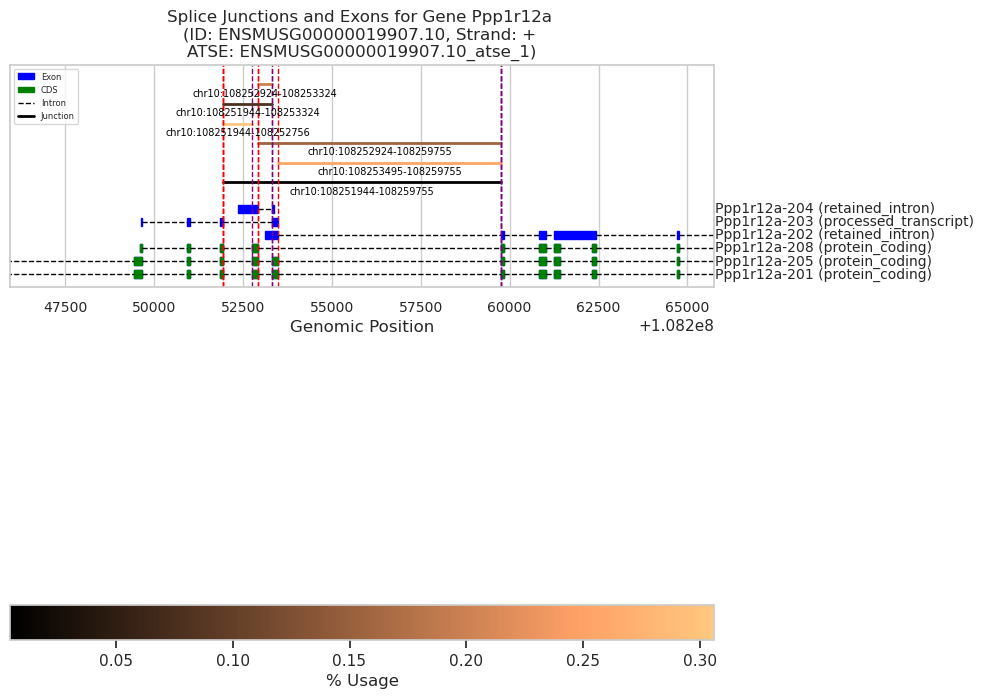

ATSE visualization saved: mouse_ENSMUSG00000019907.10_atse_1.pdf


{'junctions':                           event_id                gene_id gene_name  \
 4505  ENSMUSG00000019907.10_atse_1  ENSMUSG00000019907.10  Ppp1r12a   
 4506  ENSMUSG00000019907.10_atse_1  ENSMUSG00000019907.10  Ppp1r12a   
 4507  ENSMUSG00000019907.10_atse_1  ENSMUSG00000019907.10  Ppp1r12a   
 4508  ENSMUSG00000019907.10_atse_1  ENSMUSG00000019907.10  Ppp1r12a   
 4509  ENSMUSG00000019907.10_atse_1  ENSMUSG00000019907.10  Ppp1r12a   
 4510  ENSMUSG00000019907.10_atse_1  ENSMUSG00000019907.10  Ppp1r12a   
 
           gene_types  num_junctions event_type chromosome strand  atse_start  \
 4505  protein_coding              6    complex      chr10      +   108251944   
 4506  protein_coding              6    complex      chr10      +   108251944   
 4507  protein_coding              6    complex      chr10      +   108251944   
 4508  protein_coding              6    complex      chr10      +   108251944   
 4509  protein_coding              6    complex      chr10      +   10825194

In [23]:
mouse_event = "ENSMUSG00000019907.10_atse_1"

visualize_atse_event(mouse_event, atse_df, db_mouse, species="mouse", show_usage=True, show_junc_lines=True)

In [24]:
bladder = psi_summary[psi_summary["cell_type"] == "Bladder cell"]

# Find one highly delta_psi value 
bladder[bladder["delta_psi"] < -0.05].iloc[0]

junction_id                chr10_108253495_108259755_+
cell_type                                 Bladder cell
old                                           0.095663
young                                         0.162245
delta_psi                                    -0.066581
delta_psi_bin                                  < -0.05
annotation_status                                 both
junction_conserved                conservation_unknown
total_read_counts                               176173
non_zero_count_cells                              6984
num_junctions                                        6
non_zero_cell_prop                            0.081176
mean_counts_per_cell                                25
annotated_read_counts                           176173
unannotated_read_counts                              0
Name: 2528, dtype: object

In [25]:
# 3. Simplify annotation category
psi_summary["annotation_group"] = np.where(
    psi_summary["annotation_status"] == "both",
    "annotated",
    "unannotated"
)

# 4. Create combined label
psi_summary["annot_conserved"] = (
    psi_summary["annotation_group"] + " | " + psi_summary["junction_conserved"]
)

# 5. Add exon skipping flag if available
psi_summary["junction_id"] = psi_summary["junction_id"].astype(str)
subset["junction_id"] = subset["junction_id"].astype(str)

psi_summary = psi_summary.merge(
    subset[["junction_id", "skip_junction", "atse_event"]],
    on="junction_id",
    how="left"
)
psi_summary["skip_junction"] = psi_summary["skip_junction"].fillna(False)

File saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_coverage_vs_annotation_status_2025-08-15.pdf


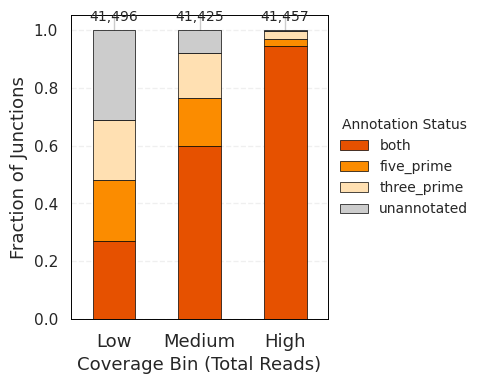

annotation_status   both  five_prime  three_prime  unannotated
coverage_bin                                                  
low                11246        8765         8539        12946
medium             24841        6767         6428         3389
high               39074        1070         1065          248


In [26]:
# Make a copy to work with
df = psi_summary.drop_duplicates(subset=["junction_id", "annotation_status", "non_zero_count_cells", "total_read_counts"])

# Bin coverage: use non-zero cell count or total reads
df["coverage_bin"] = pd.qcut(df["total_read_counts"], q=3, labels=["low", "medium", "high"])

# ---------- Data Aggregation ----------
# Get counts of annotation_status within each coverage_bin
coverage_counts = (
    df.groupby(["coverage_bin", "annotation_status"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["low", "medium", "high"], fill_value=0)  # Ensure bin order
)

# Compute row-wise fractions
coverage_frac = coverage_counts.div(coverage_counts.sum(axis=1), axis=0)

# ---------- Plot Setup ----------
fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Use distinct shades for annotation status
annotation_colors = {
    "both": "#e65100",
    "five_prime": "#fb8c00",
    "three_prime": "#ffe0b2",
    "unannotated": "#ccc"
}
# Match column order to colors
annotation_order = ["both", "five_prime", "three_prime", "unannotated"]

bar_container = coverage_frac[annotation_order].plot(
    kind="bar",
    stacked=True,
    color=[annotation_colors[k] for k in annotation_order],
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---------- Axis and Labels ----------
ax.set_ylabel("Fraction of Junctions", fontsize=13)
ax.set_xlabel("Coverage Bin (Total Reads)", fontsize=13)
ax.set_xticklabels(["Low", "Medium", "High"], rotation=0, fontsize=13)
ax.legend(title="Annotation Status", title_fontsize=11, fontsize=11, loc="upper right", frameon=True)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# ---------- Add total junction count on top of bars ----------
total_junctions_per_bin = coverage_counts.sum(axis=1)
for i, (bin_label, count) in enumerate(total_junctions_per_bin.items()):
    ax.text(i, 1.02, f"{count:,}", ha="center", va="bottom", fontsize=10)

# ---------- Set spines ----------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)

ax.legend(
    title="Annotation Status",
    title_fontsize=10,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)

# ---------- Save ----------
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"mouse_coverage_vs_annotation_status_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"File saved to {os.path.join(output_dir, f'mouse_coverage_vs_annotation_status_{today}.pdf')}")
plt.show()

# ---------- Optional Debug ----------
print(coverage_counts)

coverage_bin         low  medium   high
annotation_status                      
both               11246   24841  39074
five_prime          8765    6767   1070
three_prime         8539    6428   1065
unannotated        12946    3389    248
File saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_annotation_status_vs_coverage.pdf


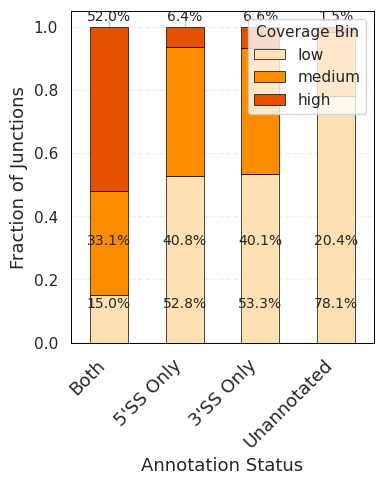

In [27]:
# ---------- Data Aggregation ----------
coverage_counts = (
    df.groupby(["annotation_status", "coverage_bin"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["low", "medium", "high"], fill_value=0)  # ensure order
)

coverage_frac = coverage_counts.div(coverage_counts.sum(axis=1), axis=0)

# ---------- Plot Setup ----------
fig, ax = plt.subplots(figsize=(4, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# colors make three shades of orange since orange is color for mouse 
colors = ["#ffe0b2", "#fb8c00", "#e65100"]

bar_container = coverage_frac.plot(
    kind="bar",
    stacked=True,
    color=colors,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# ---------- Axis and Labels ----------
ax.set_ylabel("Fraction of Junctions", fontsize=13)
ax.set_xlabel("Annotation Status", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=13)
# Place legend on the right
ax.legend(title="Coverage Bin", title_fontsize=11, fontsize=11, loc="upper right", frameon=True) 
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# ---------- Add fraction labels on top of high bin ----------
# Show percentage of junctions in each bin
for i, status in enumerate(coverage_frac.index):
    frac = coverage_frac.loc[status, "high"]
    total = coverage_counts.loc[status].sum()
    percent = frac * 100
    ax.text(i, 1.01, f"{percent:.1f}%", ha="center", va="bottom", fontsize=10)
    # show medium and low
    frac_medium = coverage_frac.loc[status, "medium"]
    percent_medium = frac_medium * 100
    ax.text(i, 0.3, f"{percent_medium:.1f}%", ha="center", va="bottom", fontsize=10)
    frac_low = coverage_frac.loc[status, "low"]
    percent_low = frac_low * 100
    ax.text(i, 0.1, f"{percent_low:.1f}%", ha="center", va="bottom", fontsize=10)

# ---------- Set spines ----------
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.7)

# Rename xaxis labels to "Both", "5'SS Only", "3'SS Only", "Unannotated"
ax.set_xticklabels(["Both", "5'SS Only", "3'SS Only", "Unannotated"])

# Over ride legend position to put it outside of the plot on the right 
ax.legend(title="Coverage Bin", title_fontsize=11, fontsize=11, loc="upper right", frameon=True)

# Print breakdown of coverage by annotation status
print(coverage_counts)

# ---------- Save ----------
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "mouse_annotation_status_vs_coverage.pdf"), format="pdf", bbox_inches="tight")
print(f"File saved to {os.path.join(output_dir, 'mouse_annotation_status_vs_coverage.pdf')}")
plt.show()

### Summarize annotated vs unannoated junction read counts on cell level

In [28]:
# Step 1: Copy and ensure clean data
df = splice_adata_full.obs[["broad_cell_type", "annotated_junction_reads", "unannotated_junction_reads"]].copy()
df = df[df["annotated_junction_reads"].notna() & df["unannotated_junction_reads"].notna()]

# Step 2: Convert categorical cell type to string if needed
df["broad_cell_type"] = df["broad_cell_type"].astype(str)

# Get overall median annotated reads
overall_median_annotated = df["annotated_junction_reads"].median()

# Get overall median unannotated reads
overall_median_unannotated = df["unannotated_junction_reads"].median()

# Step 3: Compute median annotated reads per cell type for ordering
ordered_cell_types = (
    df.groupby("broad_cell_type")["annotated_junction_reads"]
    .median()
    .sort_values(ascending=False)
    .index
)

In [29]:
from matplotlib.backends.backend_pdf import PdfPages

# Set output path
output_path = os.path.join(output_dir, f"junction_reads_per_celltype_{today}.pdf")
with PdfPages(output_path) as pdf:

    # Plot 1: Annotated
    fig1 = plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df,
        x="broad_cell_type",
        y="annotated_junction_reads",
        order=ordered_cell_types,
        showfliers=False,
        linewidth=1,
        log_scale=True
    )
    plt.xticks(rotation=90)
    plt.axhline(overall_median_annotated, color="black", linestyle="--", linewidth=1)
    plt.ylabel("Annotated Junction Reads/Cell")
    plt.title("Distribution of Annotated Reads per Cell Type")
    sns.despine()
    plt.tight_layout()
    pdf.savefig(fig1)  # Save this figure to the PDF
    plt.close(fig1)    # Close to avoid display overlap

    # Plot 2: Unannotated
    fig2 = plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df,
        x="broad_cell_type",
        y="unannotated_junction_reads",
        order=ordered_cell_types,
        showfliers=False,
        linewidth=1
    )
    plt.xticks(rotation=90)
    plt.axhline(overall_median_unannotated, color="black", linestyle="--", linewidth=1)
    plt.ylabel("Unannotated Junction Reads/Cell")
    plt.title("Distribution of Unannotated Reads per Cell Type")
    sns.despine()
    plt.tight_layout()
    pdf.savefig(fig2)  # Save second figure
    plt.close(fig2)

print(f"✅ Saved both plots to: {output_path}")
print(f"Overall median annotated reads: {overall_median_annotated}")
print(f"Overall median unannotated reads: {overall_median_unannotated}")

✅ Saved both plots to: /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/junction_reads_per_celltype_2025-08-15.pdf
Overall median annotated reads: 72451.0
Overall median unannotated reads: 1076.0


In [30]:
# ---------- Shared Setup ----------
df = splice_adata_full.obs.copy()
df = df[df["age"].isin([3, 18, 24])]

df["broad_cell_type"] = df["broad_cell_type"].astype(str)
df["age"] = df["age"].astype(int)
age_order = [3, 18, 24]

# Shared color palette across both plots
cell_types = sorted(df["broad_cell_type"].unique())  # consistent order
palette = sns.color_palette("tab20", n_colors=len(cell_types))
cell_type_color_dict = dict(zip(cell_types, palette))

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_splicing_novelty_junction_level_2025-08-15.pdf


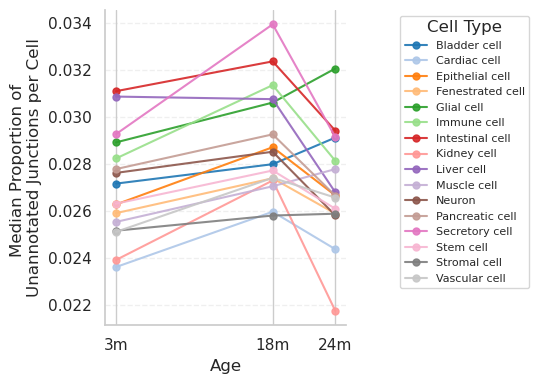

In [31]:
# Compute proportion of unannotated junctions
df["prop_unannotated_junctions"] = df["n_detected_unannotated_junctions"] / (
    df["n_detected_annotated_junctions"] + df["n_detected_unannotated_junctions"]
)

summary_junctions = (
    df.groupby(["broad_cell_type", "age"])["prop_unannotated_junctions"]
    .median()
    .reset_index()
)

summary_wide_junctions = summary_junctions.pivot(index="broad_cell_type", columns="age", values="prop_unannotated_junctions")
summary_wide_junctions = summary_wide_junctions[age_order]

# Plot
plt.figure(figsize=(6, 4))
for ct, row in summary_wide_junctions.iterrows():
    plt.plot(age_order, row.values, marker="o", label=ct,
             linewidth=1.5, markersize=5, alpha=0.9, color=cell_type_color_dict[ct])

plt.xticks(age_order, ["3m", "18m", "24m"])
plt.ylabel("Median Proportion of \nUnannotated Junctions per Cell")
plt.xlabel("Age")
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

if len(cell_types) <= 20:
    plt.legend(bbox_to_anchor=(1.2, 1), loc="upper left", fontsize=8, title="Cell Type")

plt.tight_layout()

# save plot with today 
plt.savefig(os.path.join(output_dir, f"mouse_splicing_novelty_junction_level_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"Saved to {output_dir}/mouse_splicing_novelty_junction_level_{today}.pdf")
plt.show()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_splicing_novelty_read_level_2025-08-15.pdf


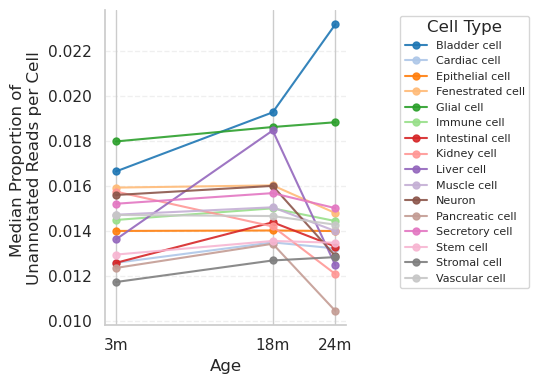

In [32]:
# Compute proportion of unannotated reads
df["prop_unannotated_reads"] = df["unannotated_junction_reads"] / (
    df["annotated_junction_reads"] + df["unannotated_junction_reads"]
)

summary_reads = (
    df.groupby(["broad_cell_type", "age"])["prop_unannotated_reads"]
    .median()
    .reset_index()
)

summary_wide_reads = summary_reads.pivot(index="broad_cell_type", columns="age", values="prop_unannotated_reads")
summary_wide_reads = summary_wide_reads[age_order]

# Plot
plt.figure(figsize=(6, 4))
for ct, row in summary_wide_reads.iterrows():
    plt.plot(age_order, row.values, marker="o", label=ct,
             linewidth=1.5, markersize=5, alpha=0.9, color=cell_type_color_dict[ct])

plt.xticks(age_order, ["3m", "18m", "24m"])
plt.ylabel("Median Proportion of \nUnannotated Reads per Cell")
plt.xlabel("Age")
plt.grid(axis="y", linestyle="--", alpha=0.3)
sns.despine()

if len(cell_types) <= 20:
    plt.legend(bbox_to_anchor=(1.2, 1), loc="upper left", fontsize=8, title="Cell Type")

plt.tight_layout()
# save plot with today 
plt.savefig(os.path.join(output_dir, f"mouse_splicing_novelty_read_level_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"Saved to {output_dir}/mouse_splicing_novelty_read_level_{today}.pdf")
plt.show()

In [33]:
# Summarize annotated vs unannotated junction reads in cell types for old and young 
# Set style
from itertools import product

sns.set_style("whitegrid", {"axes.grid": False})

# Unique values
cell_types = splice_adata_full.obs["broad_cell_type"].unique()
age_groups = splice_adata_full.obs["age_group"].unique()

# Line style map
linestyle_map = {"young": "solid", "old": "dashed"}

# Create color palette just for age groups (reused in every plot)
age_colors = dict(zip(age_groups, sns.color_palette("colorblind", len(age_groups))))

# Median lines (global)
median_annotated = splice_adata_full.obs["unannotated_junction_reads"].median()

for cell_type in cell_types:
    plt.figure(figsize=(5, 4))

    for age_group in age_groups:
        subset = splice_adata_full.obs[
            (splice_adata_full.obs["broad_cell_type"] == cell_type) &
            (splice_adata_full.obs["age_group"] == age_group)
        ]

        if len(subset) < 10:
            continue

        sns.histplot(
            data=subset,
            x="unannotated_junction_reads",
            stat="density",
            bins=30,
            element="step",
            fill=False,
            color=age_colors[age_group],
            linestyle=linestyle_map[age_group],
            label=f"{age_group} (n={len(subset)})",
            log_scale=(True, False),
            linewidth=1,
        )

    # Add global median reference
    plt.axvline(median_annotated, color="black", linestyle="--", linewidth=1)
    plt.text(median_annotated, plt.ylim()[1]*0.9, f"Median = {int(median_annotated)}",
             color="black", ha="center", va="top", fontsize=8)

    plt.title(cell_type)
    plt.xlabel("Detected Unannotated Junctions Reads")
    plt.ylabel("Density")
    plt.legend(title="Age Group", fontsize=7, title_fontsize=8, loc="upper right")
    sns.despine()
    plt.tight_layout()

    # Save per cell type
    safe_cell_type = cell_type.replace(" ", "_").replace("/", "_")
    plt.savefig(os.path.join(output_dir, f"junction_detection_coverade_{safe_cell_type}_{today}.pdf"), format="pdf", bbox_inches="tight")
    print(f"Saved: {safe_cell_type}")
    plt.close()

Saved: Epithelial_cell
Saved: Immune_cell
Saved: Vascular_cell
Saved: Muscle_cell
Saved: Stem_cell
Saved: Stromal_cell
Saved: Secretory_cell
Saved: Cardiac_cell
Saved: Pancreatic_cell
Saved: Glial_cell
Saved: Liver_cell
Saved: Fenestrated_cell
Saved: Intestinal_cell
Saved: Neuron
Saved: Kidney_cell
Saved: Bladder_cell


Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/mouse_detected_junctions_annotation_distribution_2025-08-15.pdf


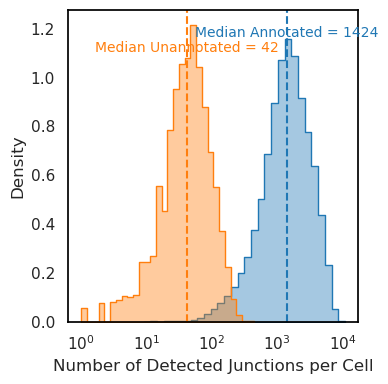

In [34]:
plt.figure(figsize=(4, 4))

# Turn off background grid
sns.set_style("whitegrid", {"axes.grid": False})

# Compute medians
median_annotated = splice_adata_full.obs["n_detected_annotated_junctions"].median()
median_unannotated = splice_adata_full.obs["n_detected_unannotated_junctions"].median()

# Annotated
sns.histplot(
    data=splice_adata_full.obs,
    x="n_detected_annotated_junctions",
    label="Annotated Junctions",
    color="tab:blue",
    element="step",
    fill=True,
    stat="density",
    bins=30,
    alpha=0.4,
    log_scale=(True, False)
)

# Unannotated
sns.histplot(
    data=splice_adata_full.obs,
    x="n_detected_unannotated_junctions",
    label="Unannotated Junctions",
    color="tab:orange",
    element="step",
    fill=True,
    stat="density",
    bins=30,
    alpha=0.4,
    log_scale=(True, False)
)

# Add vertical dashed lines for medians
plt.axvline(median_annotated, color="tab:blue", linestyle="--", linewidth=1.5)
plt.axvline(median_unannotated, color="tab:orange", linestyle="--", linewidth=1.5)

# Add text labels for medians
plt.text(median_annotated, plt.ylim()[1]*0.95, f"Median Annotated = {int(median_annotated)}",
         color="tab:blue", ha="center", va="top", fontsize=10)
plt.text(median_unannotated, plt.ylim()[1]*0.9, f"Median Unannotated = {int(median_unannotated)}",
         color="tab:orange", ha="center", va="top", fontsize=10)

plt.xlabel("Number of Detected Junctions per Cell")
plt.ylabel("Density")
# remove legend
plt.legend().remove()
# make sure black line outline is present
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')

plt.tight_layout()
# save in output directory add today to filename
plt.savefig(os.path.join(output_dir, f"mouse_detected_junctions_annotation_distribution_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"Saved to {output_dir}/mouse_detected_junctions_annotation_distribution_{today}.pdf")
plt.show()

### Otherway, is differential splicing signal stronger in younger cells (for ex liver vs kidney) than if you were to check DS in older cells for same cell type... 
- delta PSI pairwise across cell types within young and old 
- cell type by cell type heatmap of avg delta psi between those two cell types and another version for old  

In [43]:
# Initialize dict
delta_between_celltypes = {}
celltypes = splice_adata_full.obs["broad_cell_type"].unique()

# Calculate pairwise delta PSI between cell types for each age group
for age in ["young", "old"]:
    age_mask = splice_adata_full.obs["age_group"] == age
    age_data = splice_adata_full[age_mask]
    print(f"Age: {age}")
    
    ct_deltas = []
    for i, ct1 in enumerate(celltypes):
        for j, ct2 in enumerate(celltypes):
            if i < j:
                print(f"Cell type 1: {ct1}, Cell type 2: {ct2}")
                mask1 = age_data.obs["broad_cell_type"] == ct1
                mask2 = age_data.obs["broad_cell_type"] == ct2
                psi1 = np.array(age_data[mask1].layers["junc_ratio"].mean(axis=0)).flatten()
                psi2 = np.array(age_data[mask2].layers["junc_ratio"].mean(axis=0)).flatten()
                delta = np.abs(psi1 - psi2)
                ct_deltas.append(np.median(delta)) 
    
    delta_between_celltypes[age] = ct_deltas

# Final comparison
young_deltas = delta_between_celltypes["young"]
old_deltas = delta_between_celltypes["old"]

print(f"Mean delta PSI between cell types (young): {np.mean(young_deltas):.3f}")
print(f"Mean delta PSI between cell types (old): {np.mean(old_deltas):.3f}")


Age: young
Cell type 1: Epithelial cell, Cell type 2: Immune cell
Cell type 1: Epithelial cell, Cell type 2: Vascular cell
Cell type 1: Epithelial cell, Cell type 2: Muscle cell
Cell type 1: Epithelial cell, Cell type 2: Stem cell
Cell type 1: Epithelial cell, Cell type 2: Stromal cell
Cell type 1: Epithelial cell, Cell type 2: Secretory cell
Cell type 1: Epithelial cell, Cell type 2: Cardiac cell
Cell type 1: Epithelial cell, Cell type 2: Pancreatic cell
Cell type 1: Epithelial cell, Cell type 2: Glial cell
Cell type 1: Epithelial cell, Cell type 2: Liver cell
Cell type 1: Epithelial cell, Cell type 2: Fenestrated cell
Cell type 1: Epithelial cell, Cell type 2: Intestinal cell
Cell type 1: Epithelial cell, Cell type 2: Neuron
Cell type 1: Epithelial cell, Cell type 2: Kidney cell
Cell type 1: Epithelial cell, Cell type 2: Bladder cell
Cell type 1: Immune cell, Cell type 2: Vascular cell
Cell type 1: Immune cell, Cell type 2: Muscle cell
Cell type 1: Immune cell, Cell type 2: Stem cell

### Do splice junction PSIs look more different in younger cells compared to older cells?

In [44]:
psi_summary["annotation_group"].value_counts()

annotation_group
annotated      1202576
unannotated     787472
Name: count, dtype: int64

In [45]:
# convert delta_between_celltypes to dataframe
delta_between_celltypes_df = pd.DataFrame(delta_between_celltypes)

# plot heatmap of delta_between_celltypes_df
delta_between_celltypes_df

celltypes = sorted(splice_adata_full.obs["broad_cell_type"].unique())
n = len(celltypes)

# Initialize empty matrices
young_mat = np.zeros((n, n))
old_mat = np.zeros((n, n))

# Fill upper triangle from your delta lists
idx = 0
for i in range(n):
    for j in range(i + 1, n):
        young_mat[i, j] = delta_between_celltypes["young"][idx]
        old_mat[i, j] = delta_between_celltypes["old"][idx]
        idx += 1

# Symmetrize (copy upper to lower)
young_mat += young_mat.T
old_mat += old_mat.T

# Convert to DataFrames for plotting
young_df = pd.DataFrame(young_mat, index=celltypes, columns=celltypes)
old_df = pd.DataFrame(old_mat, index=celltypes, columns=celltypes)

In [46]:
from matplotlib.backends.backend_pdf import PdfPages

# Define common scale across both heatmaps
combined_max = max(young_df.values.max(), old_df.values.max())
vmin, vmax = 0, combined_max
vmax = np.ceil(vmax * 10000) / 10000  # round to 4 decimal places

image_path = os.path.join(output_dir, f"pairwise_delta_psi_heatmaps_{today}.pdf")

with PdfPages(image_path) as pdf:
    fig, axs = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

    # First heatmap (no colorbar)
    im0 = sns.heatmap(
        young_df, cmap="viridis", vmin=vmin, vmax=vmax, square=True,
        ax=axs[0], cbar=False
    )
    axs[0].set_title("Pairwise ΔPSI (young)")

    # Second heatmap (no colorbar)
    im1 = sns.heatmap(
        old_df, cmap="viridis", vmin=vmin, vmax=vmax, square=True,
        ax=axs[1], cbar=False
    )
    axs[1].set_title("Pairwise ΔPSI (old)")

    # Single shared colorbar on the right
    cbar = fig.colorbar(im1.collections[0], ax=axs, orientation="vertical",
                        fraction=0.046, pad=0.04)
    cbar.set_label("ΔPSI", fontsize=12)

    pdf.savefig(fig, dpi=300)
    plt.close(fig)

print(f"Saved to {image_path}")

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/pairwise_delta_psi_heatmaps_2025-08-15.pdf


Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/pairwise_delta_psi_boxplot_2025-08-15.pdf


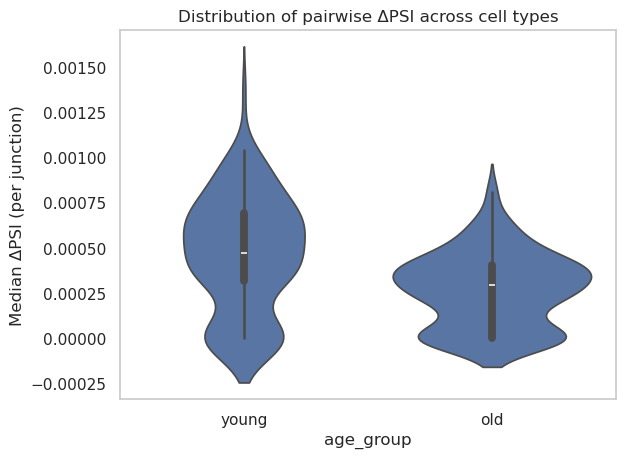

In [47]:
df = pd.DataFrame({
    "young": delta_between_celltypes["young"],
    "old": delta_between_celltypes["old"]
})
df_long = df.melt(var_name="age_group", value_name="delta_psi")

sns.violinplot(data=df_long, x="age_group", y="delta_psi")
plt.title("Distribution of pairwise ΔPSI across cell types")
plt.ylabel("Median ΔPSI (per junction)")
# save to pdf in output directory add today to filename
plt.savefig(os.path.join(output_dir, f"pairwise_delta_psi_boxplot_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"Saved to {output_dir}/pairwise_delta_psi_boxplot_{today}.pdf")
plt.show()

Saved to /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/figure_paper/pairwise_delta_psi_scatterplot_2025-08-15.pdf


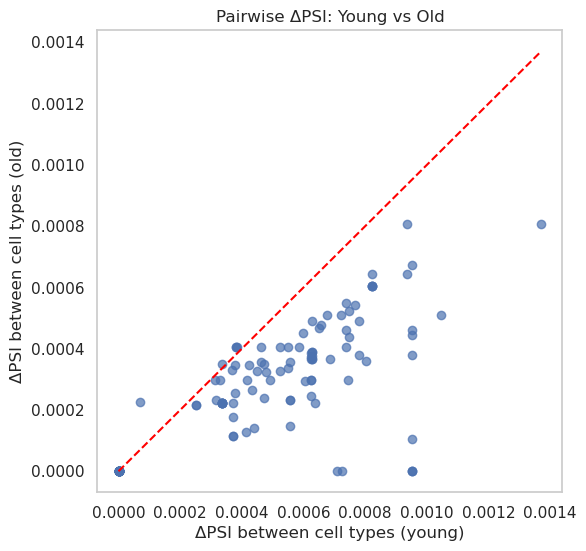

In [48]:
plt.figure(figsize=(6, 6))
plt.scatter(delta_between_celltypes["young"], delta_between_celltypes["old"], alpha=0.7)
plt.plot([0, max(delta_between_celltypes["young"])], [0, max(delta_between_celltypes["young"])], linestyle='--', color='red')
plt.xlabel("ΔPSI between cell types (young)")
plt.ylabel("ΔPSI between cell types (old)")
plt.title("Pairwise ΔPSI: Young vs Old")
# save to pdf in output directory add today to filename
plt.savefig(os.path.join(output_dir, f"pairwise_delta_psi_scatterplot_{today}.pdf"), format="pdf", bbox_inches="tight")
print(f"Saved to {output_dir}/pairwise_delta_psi_scatterplot_{today}.pdf")
plt.show()


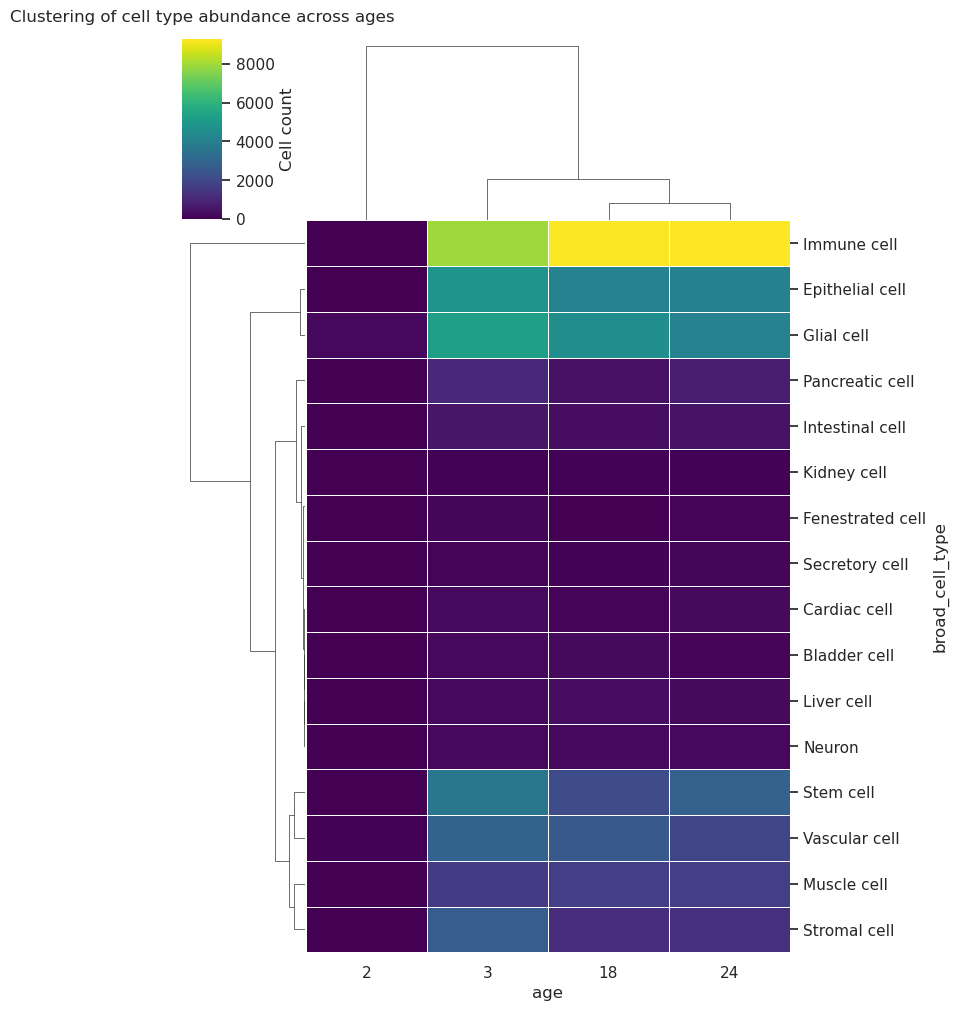

In [49]:
# Step 1: Get counts
counts = splice_adata_full.obs[["age", "broad_cell_type"]].value_counts()

# Step 2: Convert to DataFrame
counts_df = counts.reset_index(name="count")

# Step 3: Pivot to matrix format (broad_cell_type × age)
pivot_df = counts_df.pivot(index="broad_cell_type", columns="age", values="count").fillna(0)

sns.clustermap(
    pivot_df,
    cmap="viridis",
    figsize=(8, 10),
    linewidths=0.5,
    cbar_kws={"label": "Cell count"},
)
plt.title("Clustering of cell type abundance across ages", y=1.05)
plt.show()
